# 3 - Treino e validacao

Este notebook consome os artefatos salvos no pre-processamento, transforma o conjunto escolhido em sequencias temporais e executa um treino inicial de LSTM com acompanhamento em validacao. A ideia aqui e estabelecer uma base reproduzivel, nao um modelo final otimizado.


## 1. Ambiente

Se necessario:

```python
# %pip install torch pyarrow pandas numpy matplotlib
```


In [23]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

plt.rcParams["figure.figsize"] = (12, 5)

#seleciona GPU quando disponivel para acelerar o treino
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


## 2. Carga dos artefatos prontos

Por padrao, este notebook usa a versao `standard` do escalonamento. Se quiser comparar com outra estrategia, troque o valor de `SCALER_NAME`.


In [24]:
PROJECT_ROOT = Path.cwd()
PREPROCESSED_DIR = PROJECT_ROOT / "artifacts" / "preprocessed"
MODELS_DIR = PROJECT_ROOT / "artifacts" / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

#permite trocar rapidamente entre versoes de escalonamento
SCALER_NAME = "standard"

#carrega os conjuntos ja preparados na etapa anterior
train_df = pd.read_parquet(PREPROCESSED_DIR / f"train_{SCALER_NAME}.parquet")
val_df = pd.read_parquet(PREPROCESSED_DIR / f"validation_{SCALER_NAME}.parquet")

with (PREPROCESSED_DIR / "preprocessing_metadata.json").open() as fh:
    preprocessing_metadata = json.load(fh)

print(train_df.shape, val_df.shape)
print("Features:", len(preprocessing_metadata["final_feature_columns"]))


(15031, 6) (3221, 6)
Features: 6


## 3. Geracao de sequencias

Cada amostra de entrada passa a representar uma janela temporal com varias observacoes consecutivas. O alvo, neste exemplo base, e a proxima observacao multivariada da serie. A janela nao pula de bloco em bloco: ela desliza de 1 em 1 ao longo da serie temporal.


In [25]:
SEQUENCE_LENGTH = 30
BATCH_SIZE = 128


def create_sequences(dataframe: pd.DataFrame, sequence_length: int = 30):
    #transforma a serie tabular em janelas deslizantes para a LSTM
    values = dataframe.to_numpy(dtype=np.float32)
    sequences = []
    targets = []

    for start_idx in range(len(values) - sequence_length):
        end_idx = start_idx + sequence_length
        sequences.append(values[start_idx:end_idx])
        targets.append(values[end_idx])

    X = torch.tensor(np.stack(sequences), dtype=torch.float32)
    y = torch.tensor(np.stack(targets), dtype=torch.float32)
    return X, y


X_train, y_train = create_sequences(train_df, sequence_length=SEQUENCE_LENGTH)
X_val, y_val = create_sequences(val_df, sequence_length=SEQUENCE_LENGTH)

#shuffle fica desabilitado para preservar a ordem temporal das janelas
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)

print(f"X_train: {tuple(X_train.shape)} | y_train: {tuple(y_train.shape)}")
print(f"X_val:   {tuple(X_val.shape)} | y_val:   {tuple(y_val.shape)}")


X_train: (15001, 30, 6) | y_train: (15001, 6)
X_val:   (3191, 30, 6) | y_val:   (3191, 6)


### Como a janela desliza

Didaticamente, o problema configurado aqui funciona assim:

- `[t1, t2, ..., t30] -> prever t31`
- `[t2, t3, ..., t31] -> prever t32`
- `[t3, t4, ..., t32] -> prever t33`

Cada `t` acima nao e um numero unico, mas um vetor com as `6` features. Portanto, cada entrada da rede tem formato `(30, 6)` e o alvo correspondente tem formato `(6,)`. Isso significa que a LSTM observa os ultimos 30 instantes da serie e tenta prever o instante imediatamente seguinte inteiro, com todas as 6 variaveis ao mesmo tempo.


## 4. Modelo LSTM base

Esta arquitetura e propositalmente simples, para servir como baseline. Ela recebe uma janela temporal com formato `(batch, sequence_length, n_features)`, processa essa sequencia com uma LSTM de 2 camadas ocultas e 64 unidades por camada, e usa apenas o ultimo estado oculto como resumo da janela inteira. Em seguida, uma camada `Linear` transforma esse vetor final de tamanho 64 em uma saida com o mesmo numero de features da entrada, permitindo prever a proxima observacao multivariada da serie. O `dropout=0.2` atua entre as camadas recorrentes para reduzir sobreajuste. Depois que a esteira estiver estavel, vale experimentar mais camadas, outro tamanho de estado oculto, outros horizontes de previsao e selecao de features.


In [26]:
class LSTMForecaster(nn.Module):
    def __init__(self, input_size: int, hidden_size: int = 64, num_layers: int = 2, dropout: float = 0.2):
        super().__init__()
        #a LSTM extrai padroes temporais ao longo de cada janela
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
        )
        #a camada final projeta o ultimo estado oculto para o espaco das features
        self.head = nn.Linear(hidden_size, input_size)

    def forward(self, x):
        output, _ = self.lstm(x)
        #usa o ultimo passo temporal como resumo da janela inteira
        last_hidden = output[:, -1, :]
        return self.head(last_hidden)


model = LSTMForecaster(input_size=X_train.shape[-1]).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

model


LSTMForecaster(
  (lstm): LSTM(6, 64, num_layers=2, batch_first=True, dropout=0.2)
  (head): Linear(in_features=64, out_features=6, bias=True)
)

### O que a loss quer dizer aqui

A funcao de perda usada e `nn.MSELoss()`. Como a saida do modelo tem shape `(batch_size, 6)` e o alvo tambem tem shape `(batch_size, 6)`, a loss de cada batch e a media do erro quadratico de todas as 6 variaveis em todas as amostras daquele batch. Em outras palavras, a loss mostrada no treino nao e o erro de uma unica feature: ela resume o erro medio da previsao multivariada inteira. Depois, ao longo da epoca, o notebook ainda faz a media das losses dos batches para gerar a `train_loss` e a `val_loss` mostradas nos graficos.


### Esquema da arquitetura

O grafico abaixo resume o fluxo da rede: uma janela com `sequence_length = 30` passos e `n_features` variaveis entra na LSTM, a LSTM produz um estado oculto por passo temporal, e apenas o ultimo estado oculto e enviado para a camada linear final, que gera a previsao da proxima observacao da serie.


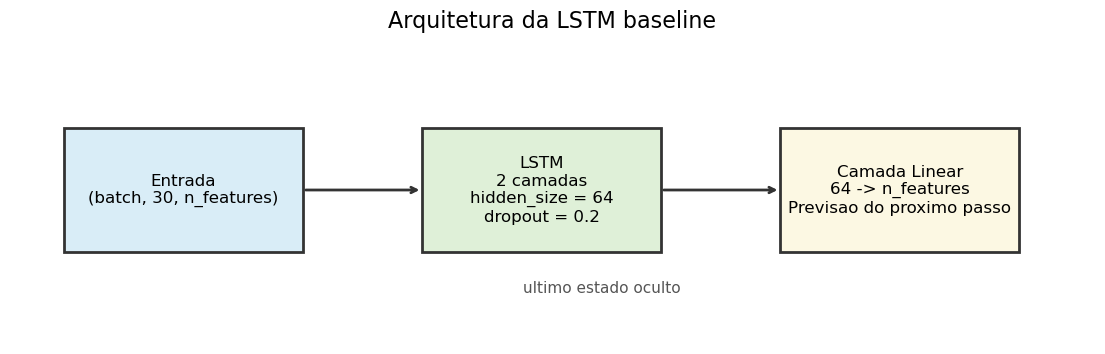

In [27]:
#monta um diagrama simples da arquitetura para facilitar interpretacao visual
fig, ax = plt.subplots(figsize=(14, 4))
ax.axis("off")

boxes = [
    (0.05, 0.3, 0.22, 0.4, "Entrada\n(batch, 30, n_features)", "#d9edf7"),
    (0.38, 0.3, 0.22, 0.4, "LSTM\n2 camadas\nhidden_size = 64\ndropout = 0.2", "#dff0d8"),
    (0.71, 0.3, 0.22, 0.4, "Camada Linear\n64 -> n_features\nPrevisao do proximo passo", "#fcf8e3"),
]

for x, y, w, h, label, color in boxes:
    rect = plt.Rectangle((x, y), w, h, facecolor=color, edgecolor="#333333", linewidth=2)
    ax.add_patch(rect)
    ax.text(x + w / 2, y + h / 2, label, ha="center", va="center", fontsize=12)

#setas entre os blocos principais
ax.annotate("", xy=(0.38, 0.5), xytext=(0.27, 0.5), arrowprops=dict(arrowstyle="->", lw=2, color="#333333"))
ax.annotate("", xy=(0.71, 0.5), xytext=(0.60, 0.5), arrowprops=dict(arrowstyle="->", lw=2, color="#333333"))

#destaca a ideia de que so o ultimo estado oculto vai para a camada final
ax.text(0.545, 0.18, "ultimo estado oculto", ha="center", va="center", fontsize=11, color="#555555")
ax.set_title("Arquitetura da LSTM baseline", fontsize=16)
plt.show()


## 5. Loop de treino e validacao

O objetivo aqui e acompanhar a curva de perda em treino e validacao para verificar se o modelo consegue aprender alguma dinamica util sem superajustar rapidamente. Em vez de treinar um numero fixo de epocas efetivas, este notebook usa `early stopping`: definimos um limite maximo de epocas, acompanhamos a `val_loss` e interrompemos o processo quando ela deixa de melhorar por varias rodadas consecutivas. Assim, o modelo salvo corresponde ao melhor checkpoint observado em validacao, e nao necessariamente ao ultimo epoch executado.


In [28]:
MAX_EPOCHS = 50
PATIENCE = 7
history = {"train_loss": [], "val_loss": []}
best_val_loss = float("inf")
best_epoch = 0
epochs_without_improvement = 0
best_model_state = None

for epoch in range(1, MAX_EPOCHS + 1):
    #fase de treino atualiza os pesos do modelo
    model.train()
    train_losses = []
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    #fase de validacao mede generalizacao sem atualizar parametros
    model.eval()
    val_losses = []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            val_losses.append(loss.item())

    epoch_train_loss = float(np.mean(train_losses))
    epoch_val_loss = float(np.mean(val_losses))
    history["train_loss"].append(epoch_train_loss)
    history["val_loss"].append(epoch_val_loss)

    #atualiza o melhor checkpoint sempre que a validacao melhora
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_epoch = epoch
        epochs_without_improvement = 0
        best_model_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    else:
        epochs_without_improvement += 1

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={epoch_train_loss:.6f} | "
        f"val_loss={epoch_val_loss:.6f} | "
        f"best_epoch={best_epoch:02d} | "
        f"patience={epochs_without_improvement}/{PATIENCE}"
    )

    #encerra o treino quando a validacao para de melhorar por varias epocas
    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping acionado na epoca {epoch:02d}. Melhor checkpoint na epoca {best_epoch:02d}.")
        break

#restaura no modelo os pesos do melhor checkpoint antes de salvar e testar
if best_model_state is not None:
    model.load_state_dict(best_model_state)


Epoch 01 | train_loss=0.637644 | val_loss=0.465290 | best_epoch=01 | patience=0/7
Epoch 02 | train_loss=0.382604 | val_loss=0.413029 | best_epoch=02 | patience=0/7
Epoch 03 | train_loss=0.227172 | val_loss=0.240185 | best_epoch=03 | patience=0/7
Epoch 04 | train_loss=0.129179 | val_loss=0.151423 | best_epoch=04 | patience=0/7
Epoch 05 | train_loss=0.074524 | val_loss=0.120588 | best_epoch=05 | patience=0/7
Epoch 06 | train_loss=0.064832 | val_loss=0.124988 | best_epoch=05 | patience=1/7
Epoch 07 | train_loss=0.059492 | val_loss=0.137802 | best_epoch=05 | patience=2/7
Epoch 08 | train_loss=0.042704 | val_loss=0.117089 | best_epoch=08 | patience=0/7
Epoch 09 | train_loss=0.044794 | val_loss=0.093828 | best_epoch=09 | patience=0/7
Epoch 10 | train_loss=0.038969 | val_loss=0.092065 | best_epoch=10 | patience=0/7
Epoch 11 | train_loss=0.028504 | val_loss=0.100118 | best_epoch=10 | patience=1/7
Epoch 12 | train_loss=0.024417 | val_loss=0.087853 | best_epoch=12 | patience=0/7
Epoch 13 | train

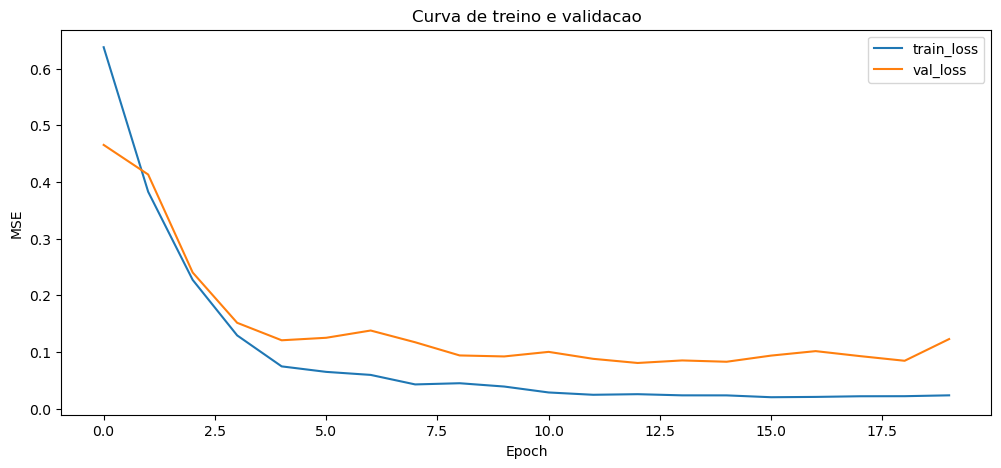

In [29]:
#organiza o historico para visualizar a evolucao das perdas
history_df = pd.DataFrame(history)
history_df.plot(title="Curva de treino e validacao")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.show()


### Graficos adicionais para interpretar o treino

Os proximos graficos ajudam a responder perguntas mais objetivas: em que ponto ocorreu o melhor checkpoint, se o gap entre treino e validacao esta crescendo demais e se o ganho do modelo ainda estava acontecendo quando o `early stopping` interrompeu o processo.


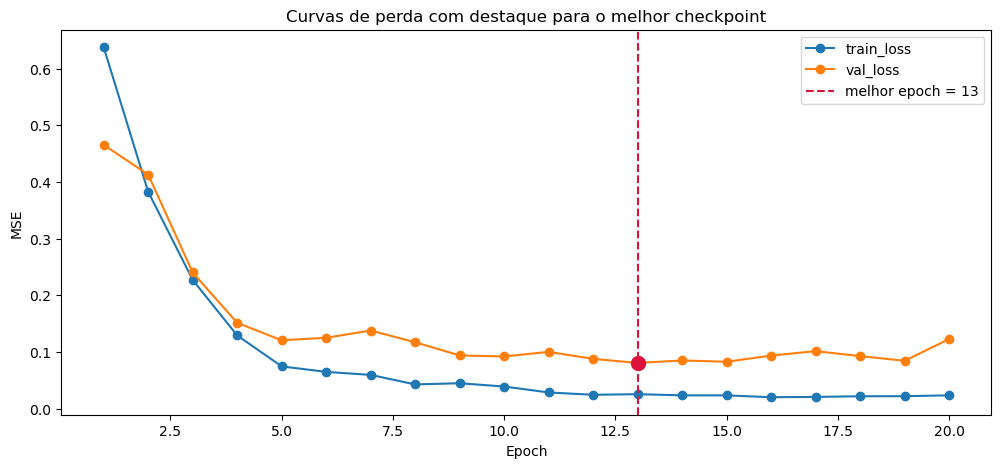

In [30]:
#marca explicitamente no grafico o melhor epoch de validacao
history_df = pd.DataFrame(history)
epochs = np.arange(1, len(history_df) + 1)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(epochs, history_df["train_loss"], marker="o", label="train_loss")
ax.plot(epochs, history_df["val_loss"], marker="o", label="val_loss")
ax.axvline(best_epoch, color="crimson", linestyle="--", label=f"melhor epoch = {best_epoch}")
ax.scatter(best_epoch, history_df.loc[best_epoch - 1, "val_loss"], color="crimson", s=100, zorder=5)
ax.set_title("Curvas de perda com destaque para o melhor checkpoint")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE")
ax.legend()
plt.show()


Neste grafico, o ponto mais importante e a linha vertical do `best_epoch`. Se a `val_loss` melhora ate esse ponto e depois passa a oscilar ou piorar, isso reforca que o melhor checkpoint foi capturado na hora certa. Se o melhor ponto ficasse muito perto do ultimo epoch executado, isso sugeriria que talvez a `patience` estivesse curta demais ou que ainda havia espaco para continuar treinando.


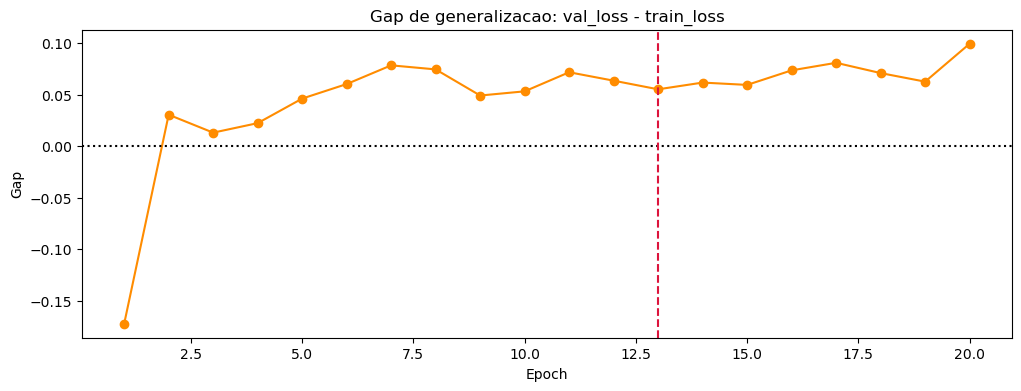

In [31]:
#mede a distancia entre validacao e treino para monitorar sobreajuste
history_df["generalization_gap"] = history_df["val_loss"] - history_df["train_loss"]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(epochs, history_df["generalization_gap"], marker="o", color="darkorange")
ax.axhline(0, color="black", linestyle=":")
ax.axvline(best_epoch, color="crimson", linestyle="--")
ax.set_title("Gap de generalizacao: val_loss - train_loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Gap")
plt.show()


O `generalization_gap` mostra o quanto a validacao esta pior do que o treino. Um gap pequeno e relativamente estavel costuma ser aceitavel. Quando esse gap cresce rapido e de forma persistente, normalmente o modelo esta aprendendo demais o treino e generalizando pior. Esse grafico e util porque, as vezes, as duas curvas ainda parecem cair, mas a distancia entre elas ja esta ficando desconfortavel.


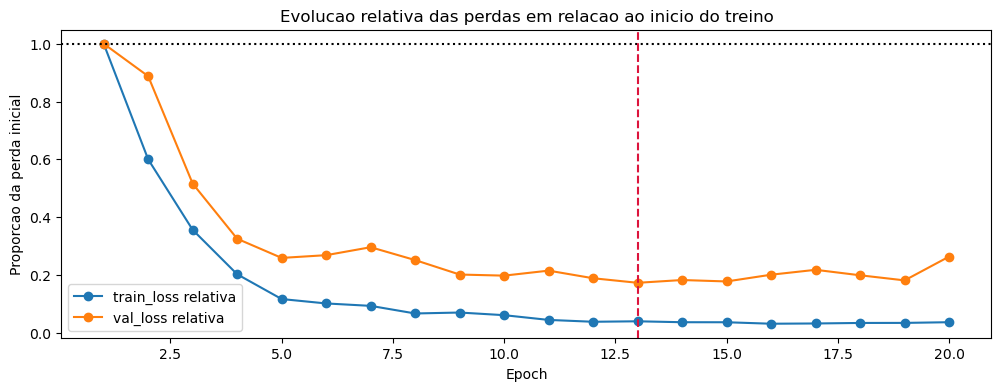

In [32]:
#compara a perda atual com a perda inicial para mostrar o ganho relativo do treino
history_df["train_loss_relativa"] = history_df["train_loss"] / history_df["train_loss"].iloc[0]
history_df["val_loss_relativa"] = history_df["val_loss"] / history_df["val_loss"].iloc[0]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(epochs, history_df["train_loss_relativa"], marker="o", label="train_loss relativa")
ax.plot(epochs, history_df["val_loss_relativa"], marker="o", label="val_loss relativa")
ax.axhline(1.0, color="black", linestyle=":")
ax.axvline(best_epoch, color="crimson", linestyle="--")
ax.set_title("Evolucao relativa das perdas em relacao ao inicio do treino")
ax.set_xlabel("Epoch")
ax.set_ylabel("Proporcao da perda inicial")
ax.legend()
plt.show()


Esse grafico ajuda a responder se o modelo realmente melhorou bastante ou apenas fez um ajuste marginal. Por exemplo, uma `val_loss_relativa` de `0.40` significa que a perda de validacao caiu para 40% do valor inicial. Quanto mais essa curva desce de forma sustentada, melhor o sinal de aprendizado. Se ela desce pouco ou volta a subir rapido, o ganho do treino foi limitado.


### Como interpretar se o resultado esta bom ou ruim

Neste notebook, o valor absoluto da perda so faz sentido em conjunto com o comportamento das curvas. Como os dados foram escalados antes do treino, um `MSE` mais baixo significa que a previsao esta mais proxima da proxima observacao real, mas nao existe um numero universal que sozinho diga se o modelo esta `bom` ou `ruim`. O que mais importa aqui e a dinamica entre treino e validacao: se as duas perdas caem juntas, o modelo esta aprendendo; se a perda de treino cai muito e a de validacao para de cair ou sobe, isso indica sobreajuste; se ambas ficam altas e quase planas, o modelo ainda nao aprendeu o suficiente e o baseline esta fraco. Em termos praticos, um baseline fica mais promissor quando a validacao cai de forma consistente, o melhor `epoch` aparece antes do limite maximo e o `early stopping` interrompe o treino sem perder o melhor checkpoint.


In [33]:
#resume quantitativamente o comportamento das curvas para facilitar interpretacao
history_df = pd.DataFrame(history)
best_train_loss = float(history_df.loc[best_epoch - 1, "train_loss"])
best_val_loss_at_epoch = float(history_df.loc[best_epoch - 1, "val_loss"])
final_train_loss = float(history_df["train_loss"].iloc[-1])
final_val_loss = float(history_df["val_loss"].iloc[-1])
final_gap = final_val_loss - final_train_loss
train_improvement = float(history_df["train_loss"].iloc[0] - final_train_loss)
val_improvement = float(history_df["val_loss"].iloc[0] - final_val_loss)

if final_gap < 0.02 and val_improvement > 0:
    diagnosis = "gap baixo e validacao em queda: baseline com sinal inicial de generalizacao saudavel"
elif final_gap < 0.08 and val_improvement > 0:
    diagnosis = "gap moderado e validacao melhorando: resultado aceitavel para um baseline, mas ainda com espaco para refinamento"
elif final_gap >= 0.08 and val_improvement > 0:
    diagnosis = "validacao melhora, mas o gap esta alto: ha indicio de sobreajuste"
else:
    diagnosis = "validacao nao melhora de forma clara: baseline ainda fraco ou mal configurado"

interpretation_df = pd.DataFrame(
    {
        "metric": [
            "melhor_epoch_validacao",
            "train_loss_no_melhor_epoch",
            "val_loss_no_melhor_epoch",
            "max_epochs_configurado",
            "patience_configurada",
            "epocas_executadas",
            "train_loss_final",
            "val_loss_final",
            "gap_final_val_minus_train",
            "queda_train_do_inicio_ao_fim",
            "queda_val_do_inicio_ao_fim",
        ],
        "value": [
            best_epoch,
            best_train_loss,
            best_val_loss_at_epoch,
            MAX_EPOCHS,
            PATIENCE,
            len(history_df),
            final_train_loss,
            final_val_loss,
            final_gap,
            train_improvement,
            val_improvement,
        ],
    }
)

display(interpretation_df)
print("Diagnostico:", diagnosis)


,metric,value
0,melhor_epoch_validacao,13.000000
1,train_loss_no_melhor_epoch,0.025471
2,val_loss_no_melhor_epoch,0.080535
3,max_epochs_configurado,50.000000
4,patience_configurada,7.000000
5,epocas_executadas,20.000000
6,train_loss_final,0.023446
7,val_loss_final,0.122736
8,gap_final_val_minus_train,0.099290
9,queda_train_do_inicio_ao_fim,0.614198


Diagnostico: validacao melhora, mas o gap esta alto: ha indicio de sobreajuste


Uma leitura pratica para este baseline: se a perda de validacao atinge um bom minimo, o `best_epoch` aparece de forma relativamente estavel e o `early stopping` interrompe o treino pouco depois, isso e um sinal saudavel de que o modelo aprendeu o que conseguia sem precisar continuar degradando a generalizacao. Se, por outro lado, a validacao estaciona cedo ou passa a piorar enquanto o treino continua caindo, isso sugere que a rede esta memorizando o treino. Nesse caso, os ajustes mais naturais sao: revisar o pre-processamento, reduzir complexidade da rede, aumentar regularizacao, mudar o `sequence_length` ou redefinir melhor o alvo da previsao.


## 6. Salvando modelo e configuracoes

O notebook de teste vai reutilizar o modelo treinado e a configuracao da sequencia temporal.


In [34]:
model_path = MODELS_DIR / "lstm_forecaster_standard.pt"
config_path = MODELS_DIR / "lstm_forecaster_standard_config.json"

#salva os pesos restaurados do melhor checkpoint encontrado em validacao
torch.save(model.state_dict(), model_path)

#salva tambem a configuracao minima para reconstruir o experimento
config = {
    "sequence_length": SEQUENCE_LENGTH,
    "input_size": int(X_train.shape[-1]),
    "hidden_size": 64,
    "num_layers": 2,
    "dropout": 0.2,
    "scaler_name": SCALER_NAME,
    "max_epochs": MAX_EPOCHS,
    "patience": PATIENCE,
    "best_epoch": best_epoch,
    "best_val_loss": best_val_loss,
    "executed_epochs": len(history["train_loss"]),
}

with config_path.open("w") as fh:
    json.dump(config, fh, indent=2)

print("Modelo salvo em:", model_path)
print("Config salvo em:", config_path)


Modelo salvo em: /Users/tiagoriosdarocha/Desktop/lstm-w3/artifacts/models/lstm_forecaster_standard.pt
Config salvo em: /Users/tiagoriosdarocha/Desktop/lstm-w3/artifacts/models/lstm_forecaster_standard_config.json


## 7. Fechamento

Se as curvas de validacao apresentarem comportamento estavel, o proximo passo e medir o desempenho no conjunto de teste sem tocar no ajuste do modelo. Isso fica centralizado em `4-teste.ipynb`.
